<a href="https://colab.research.google.com/github/Riyaaa1/Risk-score-prediction/blob/main/heart_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_palette(sns.color_palette('Paired'))

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [47]:
url = "https://raw.githubusercontent.com/ShaileshAdhikari/saviour-of-heart/main/dataset/dataset_savioroftheheart.csv"

In [48]:
#reading the data
data = pd.read_csv(url)
data.head(5)

,Sex,Age,SBP(mmHg),Treatment for Hypertension,Current Smoker,Diabetes,HDL,TCL,Risk Score,Risk Score (%)
0,m,30,90,n,n,y,10,100,0.032416,3.241608
1,m,31,95,y,y,n,15,115,0.046323,4.632346
2,f,31,90,n,y,y,20,130,0.023048,2.304822
3,f,32,95,y,y,n,25,145,0.018608,1.860786
4,m,33,100,n,y,y,30,160,0.061379,6.137861


In [49]:
data.shape

(10115, 10)

In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10115 entries, 0 to 10114
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Sex                         10115 non-null  object 
 1   Age                         10115 non-null  int64  
 2   SBP(mmHg)                   10115 non-null  int64  
 3   Treatment for Hypertension  10115 non-null  object 
 4   Current Smoker              10115 non-null  object 
 5   Diabetes                    10115 non-null  object 
 6   HDL                         10115 non-null  int64  
 7   TCL                         10115 non-null  int64  
 8   Risk Score                  10115 non-null  float64
 9   Risk Score (%)              10115 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 790.4+ KB


In [51]:
# checking for any missing values
data.isna().sum()

Sex                           0
Age                           0
SBP(mmHg)                     0
Treatment for Hypertension    0
Current Smoker                0
Diabetes                      0
HDL                           0
TCL                           0
Risk Score                    0
Risk Score (%)                0
dtype: int64

In [52]:
# summary statistics of given data
data.describe()

,Age,SBP(mmHg),HDL,TCL,Risk Score,Risk Score (%)
count,10115.000000,10115.000000,10115.000000,10115.000000,10115.000000,10115.000000
mean,52.035195,144.325260,54.412358,252.418784,0.284577,28.457680
std,13.058460,32.808286,26.278161,88.201082,0.246664,24.666374
min,30.000000,22.000000,10.000000,100.000000,0.002894,0.289403
25%,41.000000,117.000000,32.000000,177.000000,0.089754,8.975380
50%,52.000000,144.000000,53.000000,250.000000,0.203342,20.334206
75%,63.000000,173.000000,77.000000,329.000000,0.410746,41.074556
max,74.000000,200.000000,100.000000,405.000000,0.999996,99.999595


<AxesSubplot:>

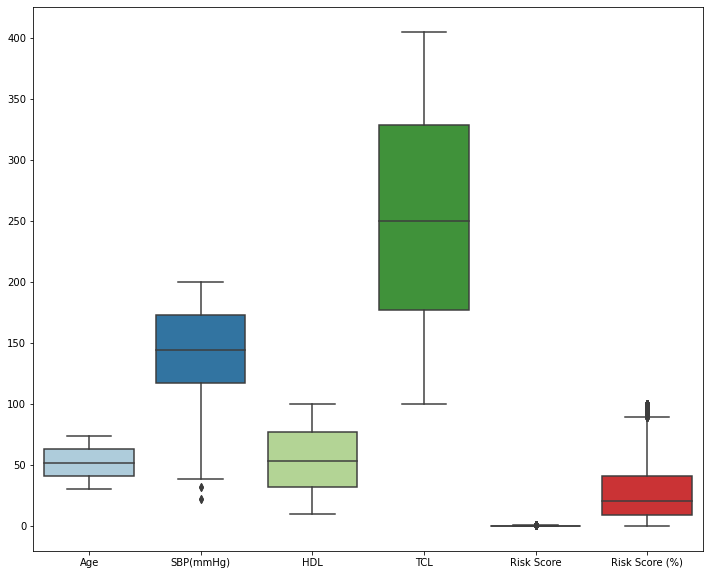

In [53]:
# checking for any outliers
plt.figure(figsize=(12,10))
sns.boxplot(data=data)

In [54]:
# dropping one of the two target variables
data = data.drop(['Risk Score (%)'],axis=1)

In [55]:
# this function replaces spaces within column names with "_"
def rep_space(name):
    new_name=[]
    for i in name:
        i=i.replace(" ","_")
        new_name.append(i)
    return(new_name)
new_col_name= rep_space(data.columns)
new_col_name

['Sex',
 'Age',
 'SBP(mmHg)',
 'Treatment_for_Hypertension',
 'Current_Smoker',
 'Diabetes',
 'HDL',
 'TCL',
 'Risk_Score']

In [56]:
#renaming the column names with new column names
data.rename(columns=dict(zip(data.columns,new_col_name)),inplace=True)

In [57]:
data.head()

,Sex,Age,SBP(mmHg),Treatment_for_Hypertension,Current_Smoker,Diabetes,HDL,TCL,Risk_Score
0,m,30,90,n,n,y,10,100,0.032416
1,m,31,95,y,y,n,15,115,0.046323
2,f,31,90,n,y,y,20,130,0.023048
3,f,32,95,y,y,n,25,145,0.018608
4,m,33,100,n,y,y,30,160,0.061379


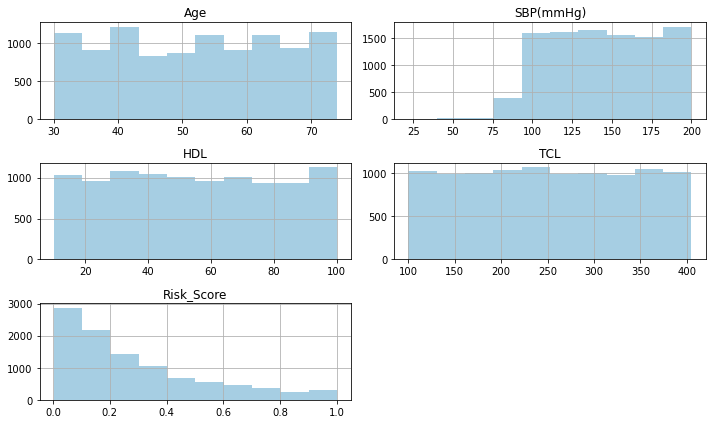

In [58]:
data.hist()
plt.tight_layout()

1.09757205149937

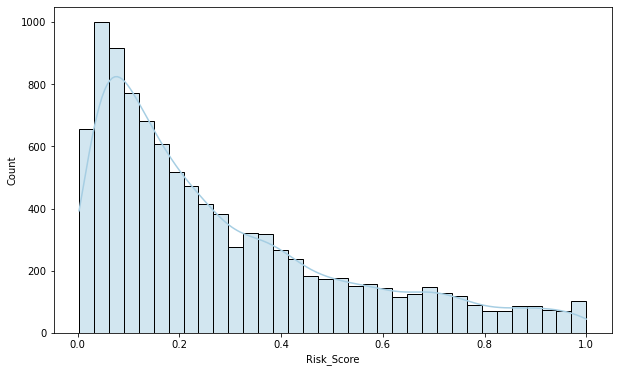

In [59]:
#histogram plot for the target variable
sns.histplot(data['Risk_Score'],kde=True)
data['Risk_Score'].skew()

Here,looking at above histogram for our target variable ,the distribution for risk score is right tailed(positively skewed)

In [60]:
# normalising the target variable using boxcox transformation
from scipy import stats
data['b_RiskScore']=stats.boxcox(data['Risk_Score'])[0]

-0.05799675074652804

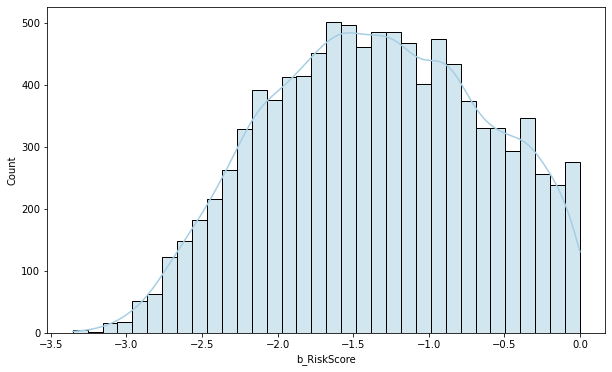

In [61]:
sns.histplot(data['b_RiskScore'],kde=True)
pd.Series(data['b_RiskScore']).skew()

c:\Users\user\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<Figure size 792x576 with 0 Axes>

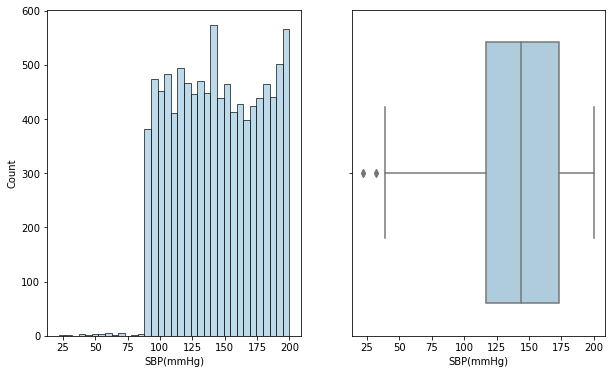

In [62]:
plt.figure(figsize=(11,8))
fig, axes = plt.subplots(1, 2)

sns.histplot(data['SBP(mmHg)'],ax=axes[0])
sns.boxplot(data['SBP(mmHg)'],ax=axes[1])
plt.show()

In [63]:
# this function returns the outliers in the SBP column that we saw earlier in the boxplot and histogram above
def outlier_detection(dataframe):
  Q1 = dataframe.quantile(0.25)
  Q3 = dataframe.quantile(0.75)
  IQR = Q3 - Q1
  upper_end = Q3 + 1.5 * IQR
  lower_end = Q1 - 1.5 * IQR 
  outlier = dataframe[(dataframe > upper_end) | (dataframe < lower_end)]
  return outlier

In [64]:
SBP_outliers=outlier_detection(data['SBP(mmHg)'])
print(f"Outlier in column SBP(mmHg):\n{SBP_outliers}")

Outlier in column SBP(mmHg):
63      22
75      32
7140    22
7152    32
Name: SBP(mmHg), dtype: int64


In [65]:
# dropping these outliers from the data set
df = data.drop([63,75,7140,7152])
df.shape

(10111, 10)

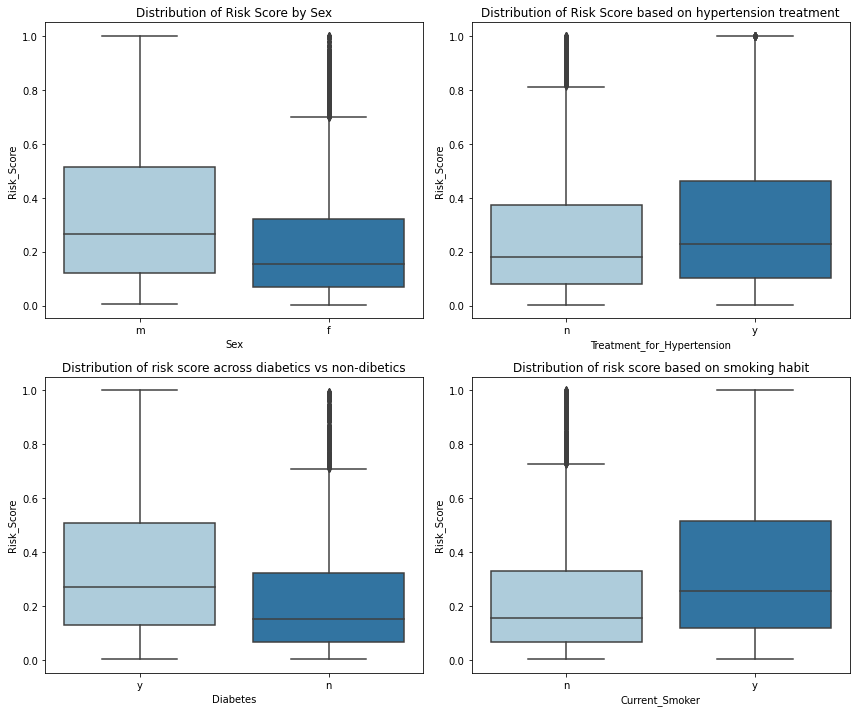

In [66]:
# plotting each categorical variables with respect to target
fig, axes=plt.subplots(2,2,figsize = (12,10))

sns.boxplot(x='Sex',y='Risk_Score',data=df,ax = axes[0,0])
axes[0,0].set_title('Distribution of Risk Score by Sex')

sns.boxplot(x='Treatment_for_Hypertension',y='Risk_Score',data=df,ax=axes[0,1])
axes[0,1].set_title('Distribution of Risk Score based on hypertension treatment')

sns.boxplot(x='Diabetes',y='Risk_Score',data=df,ax=axes[1,0])
axes[1,0].set_title("Distribution of risk score across diabetics vs non-dibetics")

sns.boxplot(x='Current_Smoker',y='Risk_Score',data=df,ax=axes[1,1])
axes[1,1].set_title("Distribution of risk score based on smoking habit")

fig.tight_layout()

Here,I have plotted each categorical variables against our target variable.Based on these boxplots,we can tell that
* Risk score is generally higher amongst males than female subjects in our dataset
* Diabetics are at higher risk for developing heart condition compared to non-diabetics
* Smokers have higher risk score than non-smokers 
*Those taking treatment for Hypertension have higher risk scores.

<AxesSubplot:>

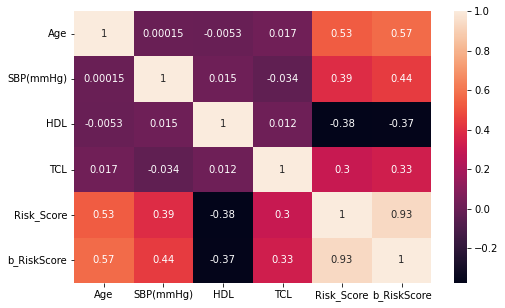

In [67]:
# looking into correlation between variables
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(),annot = True,cbar=True)

* correlation coefficient ranges from -1 to +1
* Sign(+/-) indicate the direction and amount indicate the strength of correlation
* 'Age','SBP(mmHg)','TCL' are positively correlated to risk score while 'HDL' is negatively correlated.
* Also, there seems to be no case of multicollinearity

<AxesSubplot:xlabel='Age', ylabel='b_RiskScore'>

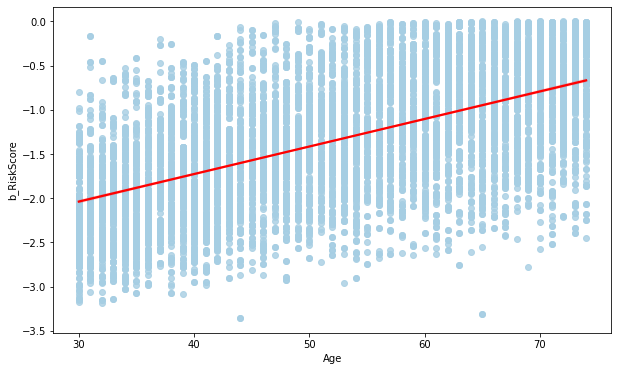

In [68]:
# visualising regression plot for each independent variables and the target
sns.regplot(x='Age',y='b_RiskScore',data=df,line_kws={'color':'red'})

<AxesSubplot:xlabel='SBP(mmHg)', ylabel='b_RiskScore'>

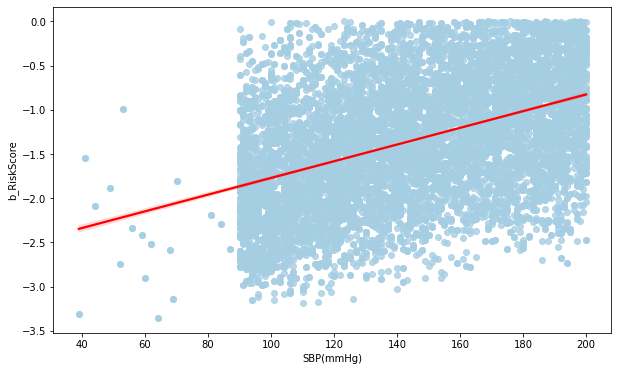

In [69]:
sns.regplot(x='SBP(mmHg)',y='b_RiskScore',data=df,line_kws={'color':'red'})

<AxesSubplot:xlabel='HDL', ylabel='b_RiskScore'>

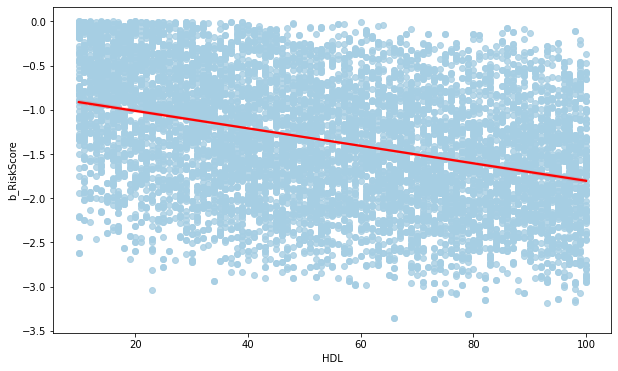

In [70]:
sns.regplot(x='HDL',y='b_RiskScore',data=data,line_kws={'color':'red'})

<AxesSubplot:xlabel='TCL', ylabel='b_RiskScore'>

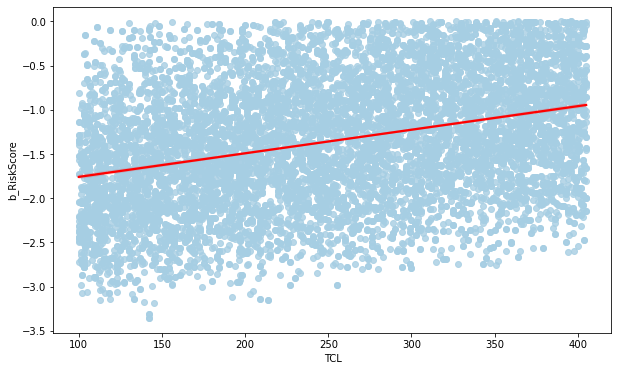

In [71]:
sns.regplot(x='TCL',y='b_RiskScore',data=data,line_kws={'color':'red'})

In [72]:
data.head()

,Sex,Age,SBP(mmHg),Treatment_for_Hypertension,Current_Smoker,Diabetes,HDL,TCL,Risk_Score,b_RiskScore
0,m,30,90,n,n,y,10,100,0.032416,-2.439091
1,m,31,95,y,y,n,15,115,0.046323,-2.259489
2,f,31,90,n,y,y,20,130,0.023048,-2.598471
3,f,32,95,y,y,n,25,145,0.018608,-2.692763
4,m,33,100,n,y,y,30,160,0.061379,-2.108042


In [73]:
df = data.drop(['Risk_Score'],axis=1)

In [74]:
# selecting X's and Y
y= df['b_RiskScore']
not_y= data.drop(['b_RiskScore','Risk_Score'],axis=1)

In [75]:
# creating dummy variable for categorical variables
x= pd.get_dummies(not_y,drop_first=True)

In [76]:
x.head()

,Age,SBP(mmHg),HDL,TCL,Sex_m,Treatment_for_Hypertension_y,Current_Smoker_y,Diabetes_y
0,30,90,10,100,1,0,0,1
1,31,95,15,115,1,1,1,0
2,31,90,20,130,0,0,1,1
3,32,95,25,145,0,1,1,0
4,33,100,30,160,1,0,1,1


In [77]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [78]:
print(x.shape,x_train.shape,x_test.shape)

(10115, 8) (8092, 8) (2023, 8)


In [79]:
scaler= StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [80]:
lr = LinearRegression()
lr.fit(x_train_scaled,y_train.values)

LinearRegression()

In [81]:
y_pred = lr.predict(x_test_scaled)

In [82]:
#evaluation metrics
r2score = r2_score(y_pred,y_test)# difference between the samples in dataset and predictions model has made --closer to 1 , the better it is
mae = mean_absolute_error(y_pred,y_test) # mae measures how far the predictions are from the actual value, so lower the mae the better
mse = mean_squared_error(y_pred,y_test)
print(f"r2score:{r2score}\nmean absolute score:{mae}\nmean squared error:{mse}")

r2score:0.9516024891752396
mean absolute score:0.11763353858182171
mean squared error:0.02298222495220207


In [83]:
residuals = y_pred-y_test

<AxesSubplot:xlabel='b_RiskScore', ylabel='Count'>

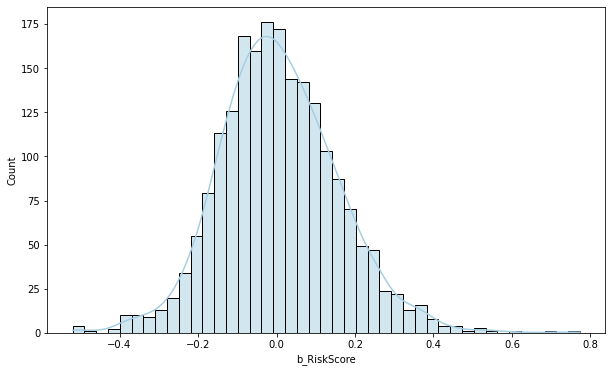

In [84]:
sns.histplot(residuals,kde=True)

Text(0.5, 1.0, 'Actual vs Predicted values')

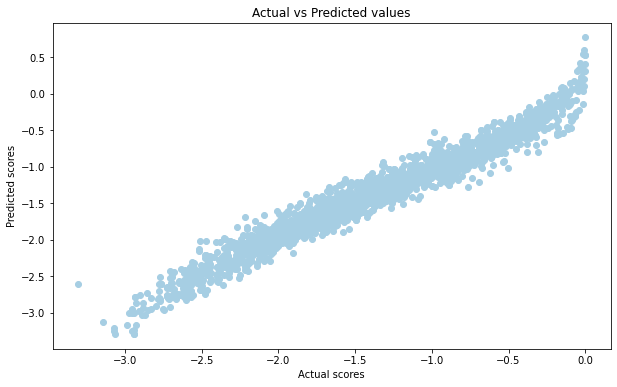

In [85]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual scores')
plt.ylabel('Predicted scores')
plt.rcParams["figure.figsize"] = (10,6) 
plt.title("Actual vs Predicted values")

In [86]:
import pickle
pickle_out = open('regressor.pkl',mode='wb')
pickle.dump(lr,pickle_out)
pickle_out.close()